## AoI 스케일 조정을 위한 rational mapping 테스트

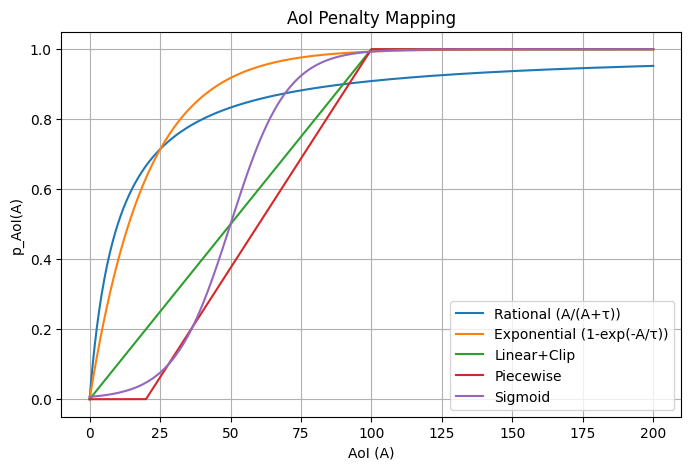

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# AoI range
A = np.linspace(0, 200, 1000)  # 필요에 따라 범위 조정

# ===== Mapping functions =====

# 1) Rational mapping
def p_rational(A, tau=10):
    return A / (A + tau)

# 2) Exponential mapping
def p_exponential(A, tau=20):
    return 1 - np.exp(-A / tau)

# 3) Linear + clipping
def p_linear_clip(A, A_ref=100):
    return np.minimum(A / A_ref, 1.0)

# 4) Piecewise
def p_piecewise(A, A_good=20, A_bad=100):
    p = np.zeros_like(A)
    p[A >= A_bad] = 1.0
    mask = (A > A_good) & (A < A_bad)
    p[mask] = (A[mask] - A_good) / (A_bad - A_good)
    return p

# 5) Sigmoid (with shift & scale)
def p_sigmoid(A, tau=50, s=10):
    return 1 / (1 + np.exp(-(A - tau) / s))


# ===== Compute =====
p1 = p_rational(A)
p2 = p_exponential(A)
p3 = p_linear_clip(A)
p4 = p_piecewise(A)
p5 = p_sigmoid(A)


# ===== Plot =====
plt.figure(figsize=(8, 5))

plt.plot(A, p1, label='Rational (A/(A+τ))')
plt.plot(A, p2, label='Exponential (1-exp(-A/τ))')
plt.plot(A, p3, label='Linear+Clip')
plt.plot(A, p4, label='Piecewise')
plt.plot(A, p5, label='Sigmoid')

plt.xlabel('AoI (A)')
plt.ylabel('p_AoI(A)')
plt.title('AoI Penalty Mapping')
plt.legend()
plt.grid()

plt.show()